In [ ]:
!pip install pymoo numpy pandas matplotlib


Processing Function: ZDT1 (SGMGPSO)
  Trial 30/30 running...
  [Done] ZDT1 — 30 trials completed.
  Summary: IGD Mean = 0.026439 ± 0.009233
           HV Mean  = 5.731267 ± 0.041037


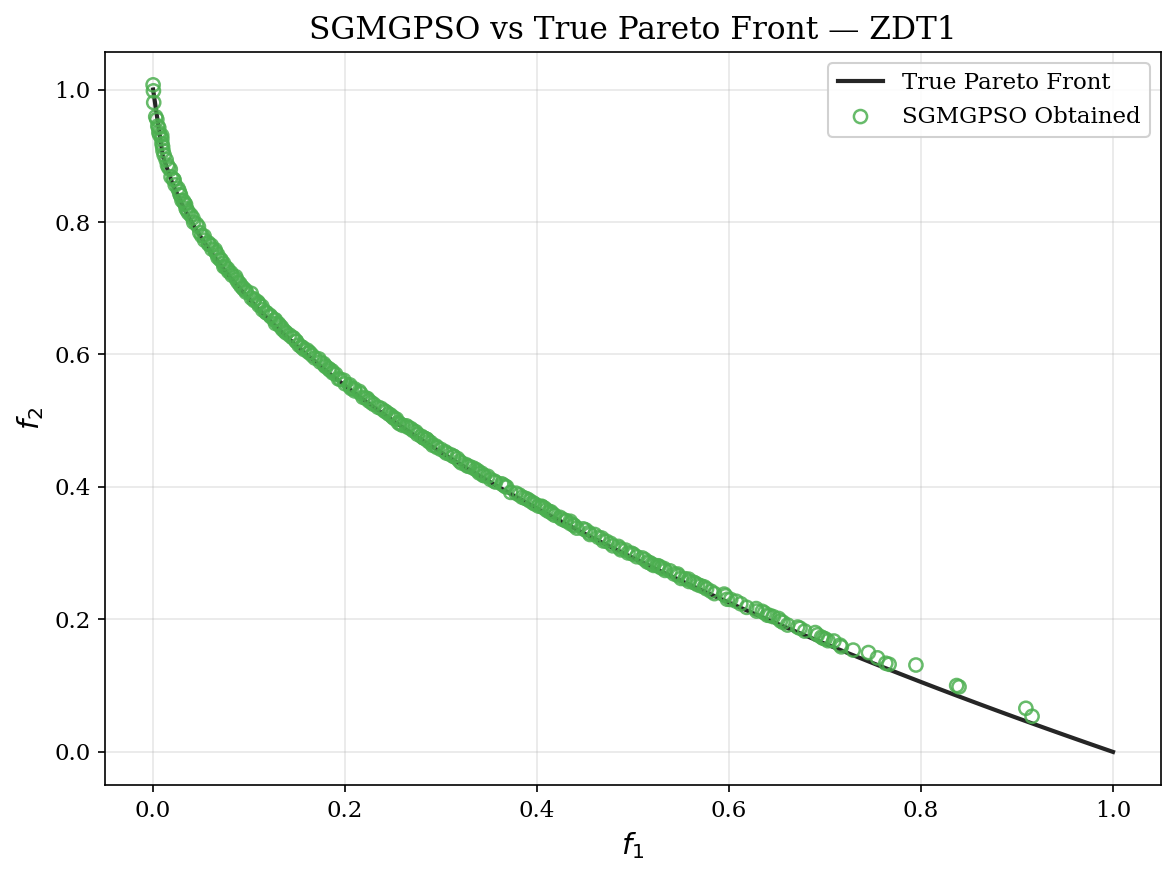


Processing Function: ZDT2 (SGMGPSO)
  Trial 30/30 running...
  [Done] ZDT2 — 30 trials completed.
  Summary: IGD Mean = 0.076911 ± 0.039952
           HV Mean  = 4.856004 ± 0.300673


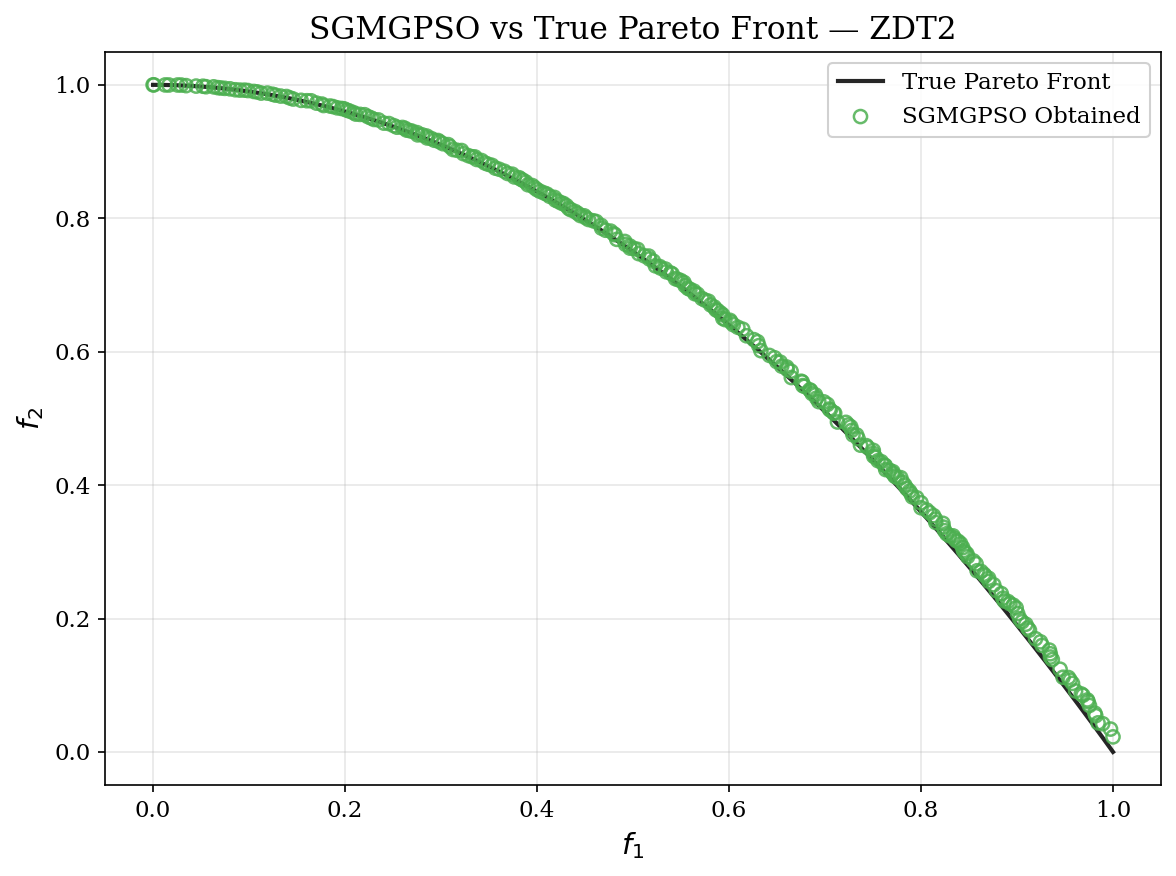


Processing Function: ZDT3 (SGMGPSO)
  Trial 30/30 running...
  [Done] ZDT3 — 30 trials completed.
  Summary: IGD Mean = 0.071133 ± 0.020922
           HV Mean  = 6.846284 ± 0.150167


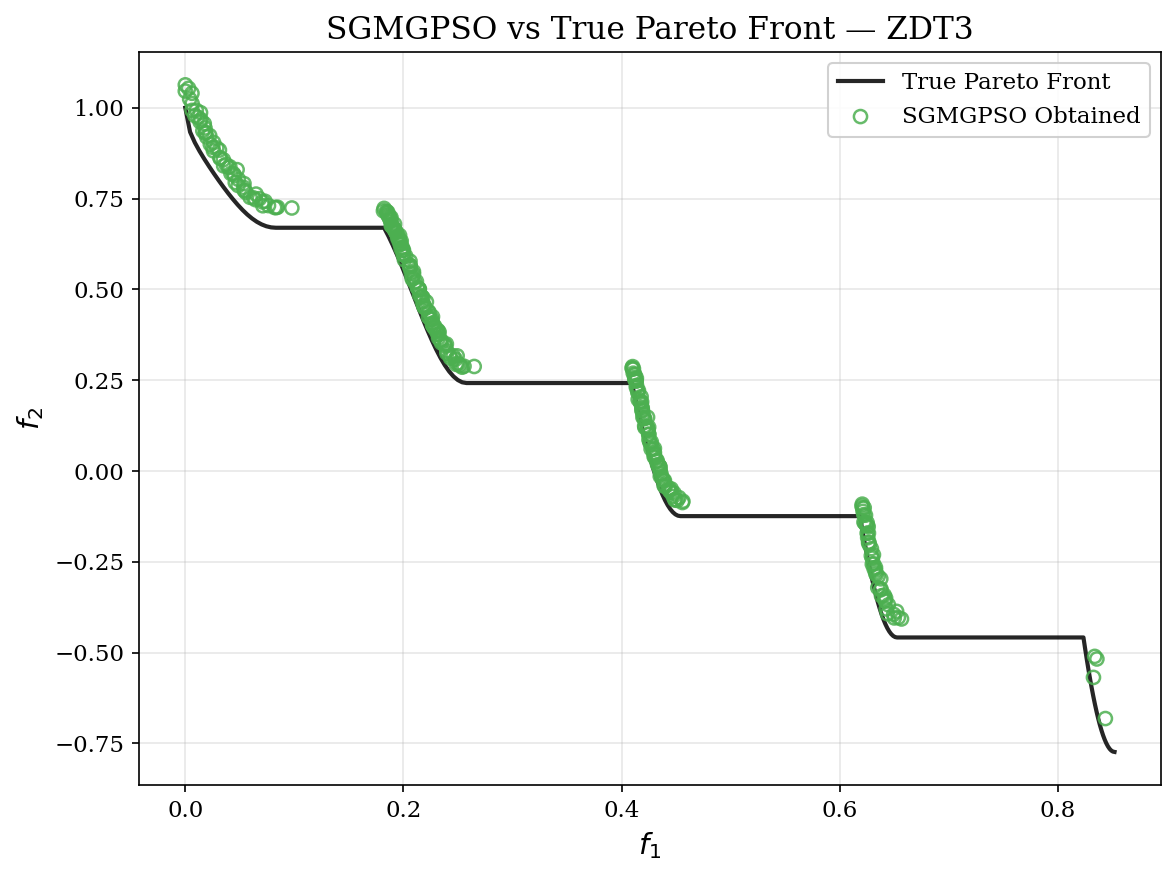


Processing Function: ZDT4 (SGMGPSO)
  Trial 30/30 running...
  [Done] ZDT4 — 30 trials completed.
  Summary: IGD Mean = 14.233360 ± 2.577257
           HV Mean  = 0.000000 ± 0.000000


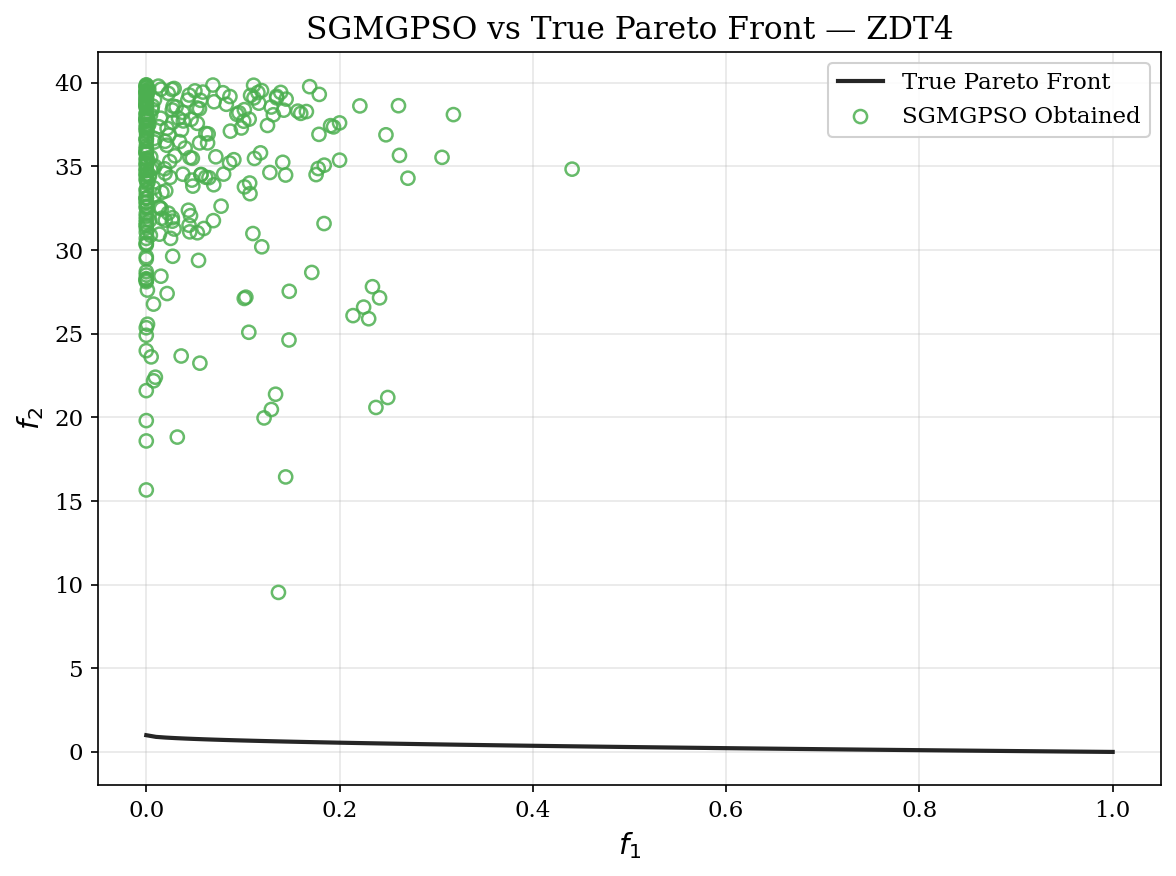


Processing Function: ZDT6 (SGMGPSO)
  Trial 30/30 running...
  [Done] ZDT6 — 30 trials completed.
  Summary: IGD Mean = 0.001131 ± 0.000089
           HV Mean  = 5.153512 ± 0.000028


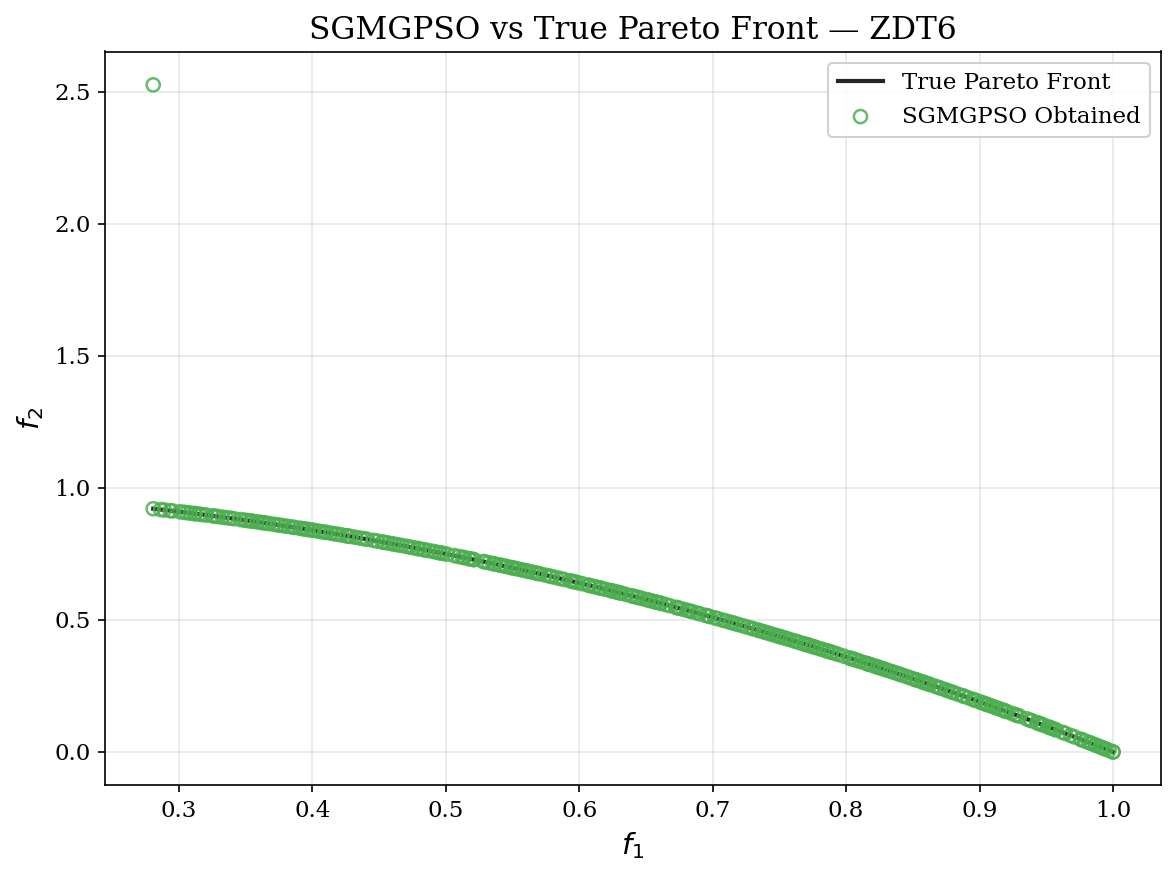


Processing Function: WFG1 (SGMGPSO)
  Trial 30/30 running...
  [Done] WFG1 — 30 trials completed.
  Summary: IGD Mean = 1.441356 ± 0.033543
           HV Mean  = 44.527959 ± 1.104315


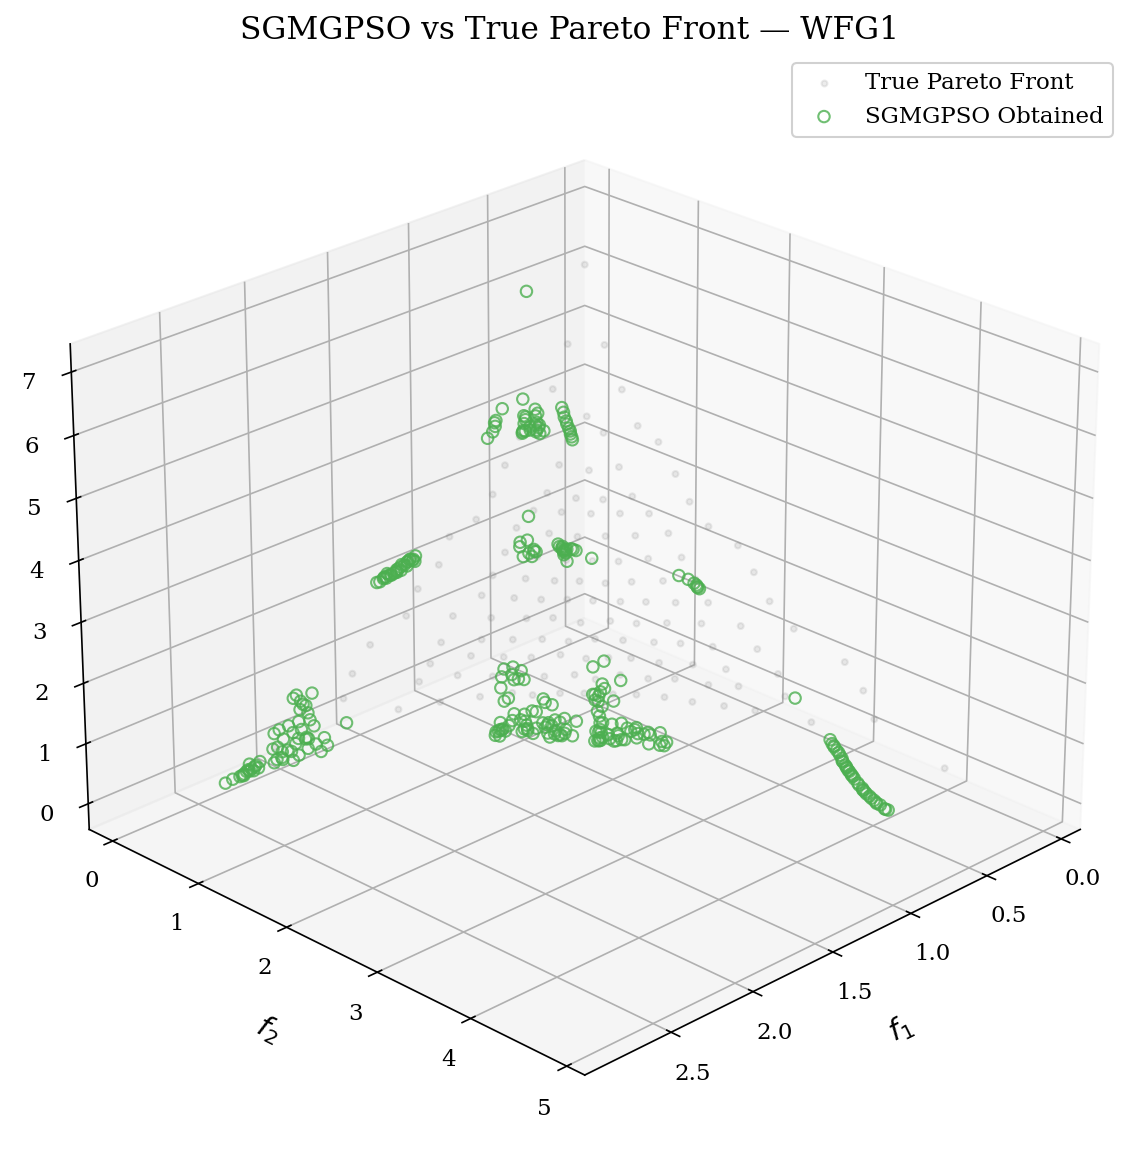


Processing Function: WFG2 (SGMGPSO)
  Trial 30/30 running...
  [Done] WFG2 — 30 trials completed.
  Summary: IGD Mean = 0.276901 ± 0.060657
           HV Mean  = 91.832459 ± 2.454494


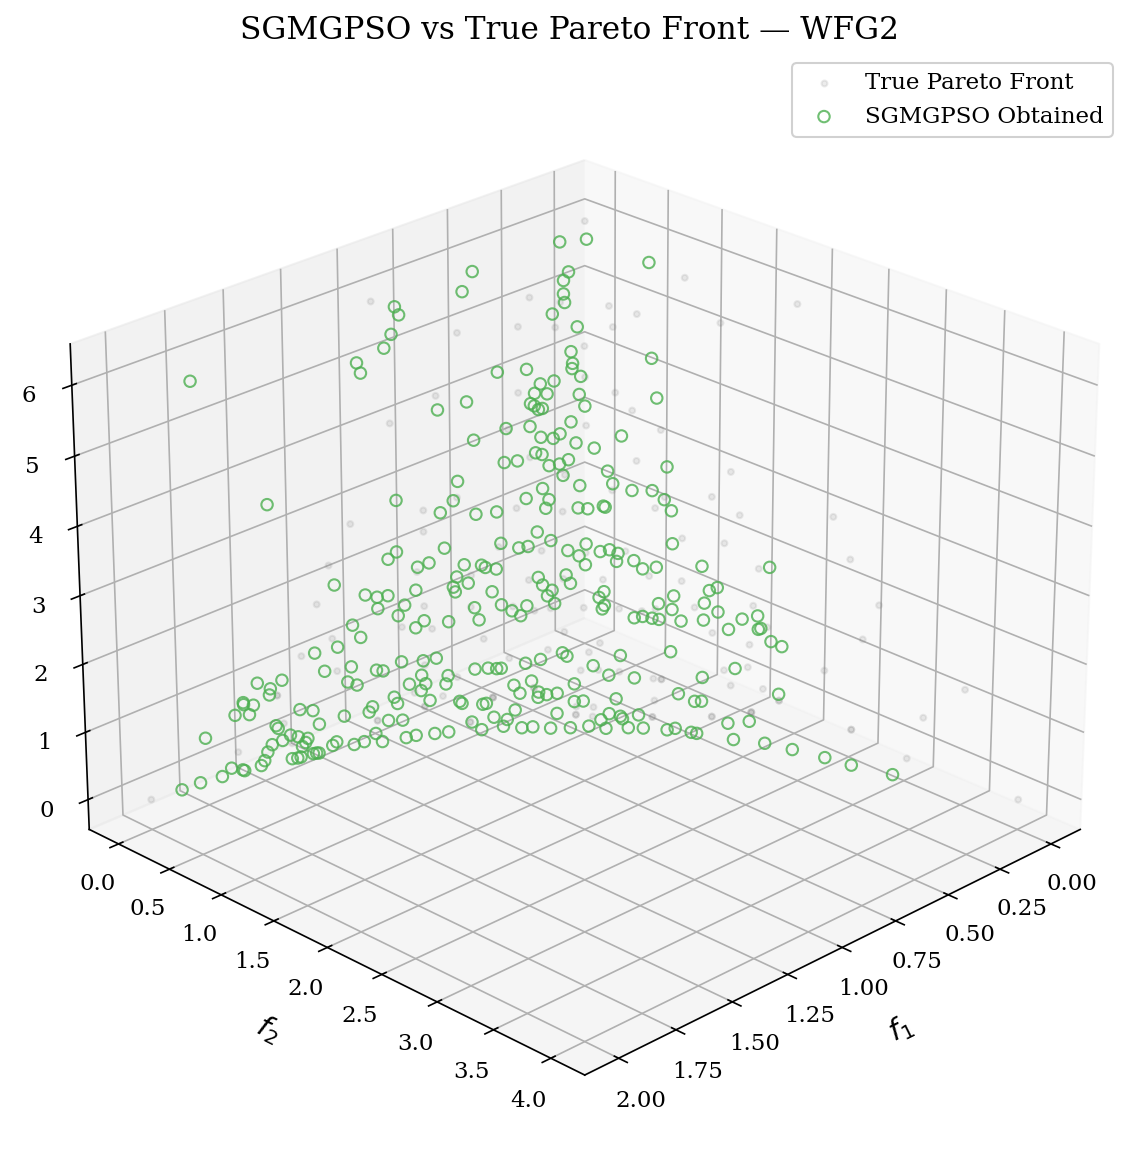


Processing Function: WFG3 (SGMGPSO)
  Trial 30/30 running...
  [Done] WFG3 — 30 trials completed.
  Summary: IGD Mean = 0.271304 ± 0.016832
           HV Mean  = 64.155366 ± 0.591565


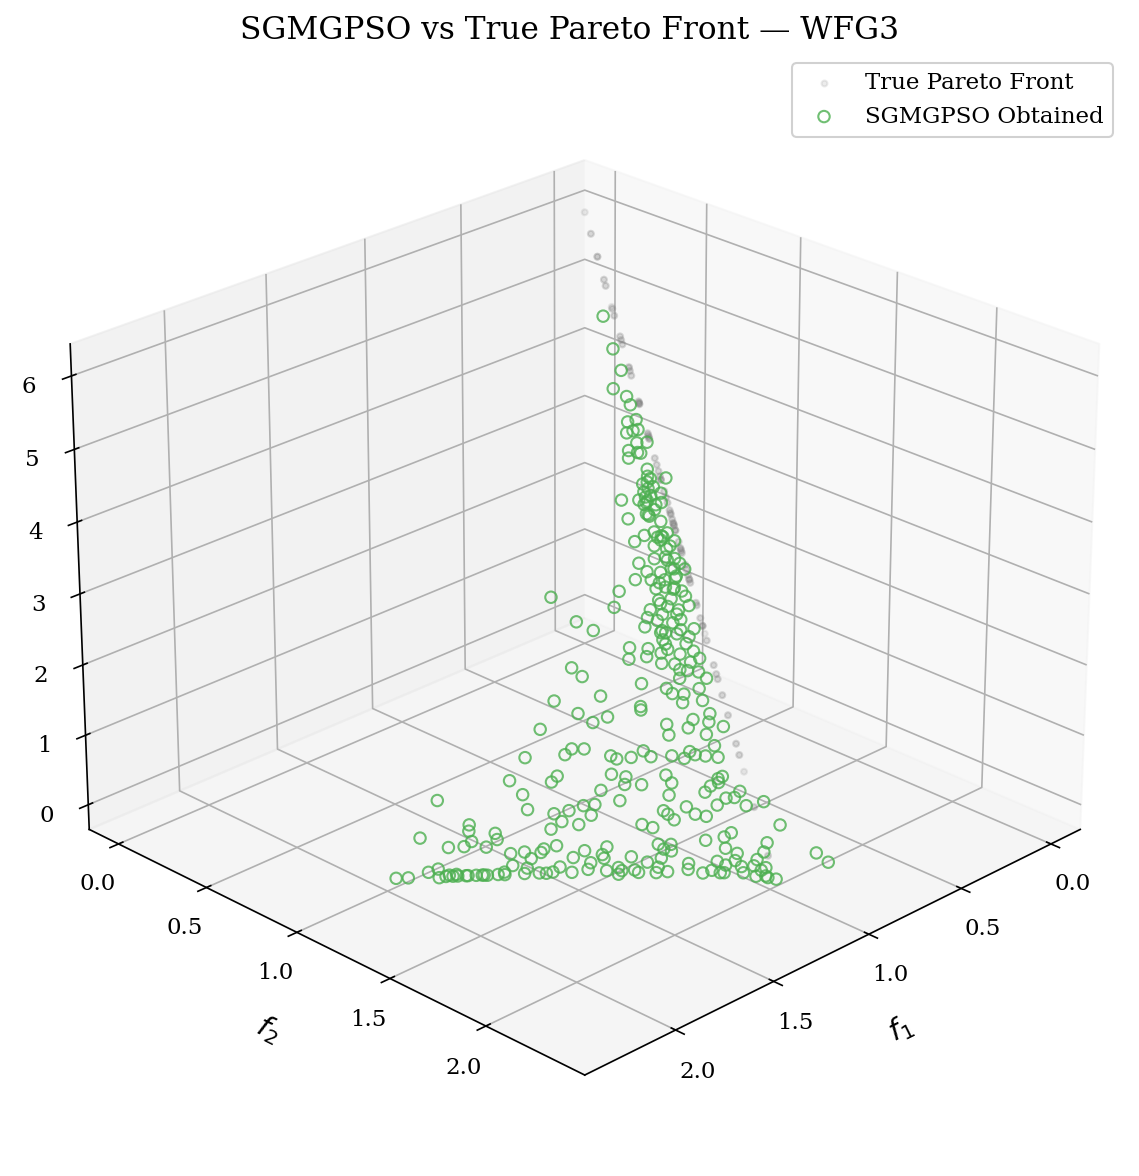


Processing Function: WFG4 (SGMGPSO)
  Trial 30/30 running...
  [Done] WFG4 — 30 trials completed.
  Summary: IGD Mean = 0.235642 ± 0.008257
           HV Mean  = 69.378567 ± 0.458237


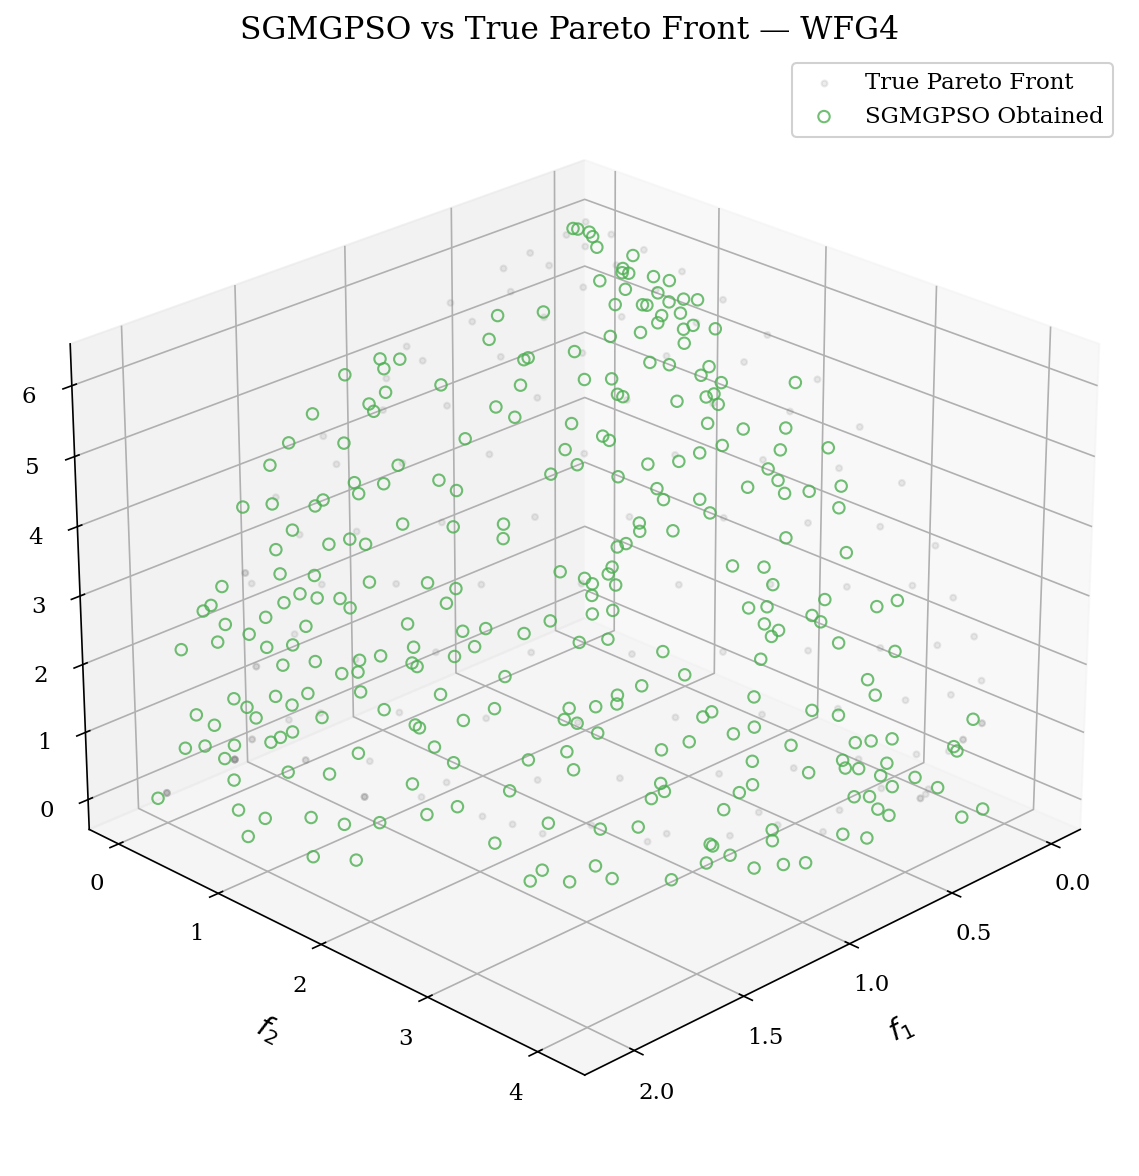


Processing Function: WFG5 (SGMGPSO)
  Trial 30/30 running...
  [Done] WFG5 — 30 trials completed.
  Summary: IGD Mean = 0.761689 ± 0.120961
           HV Mean  = 44.466620 ± 4.999990


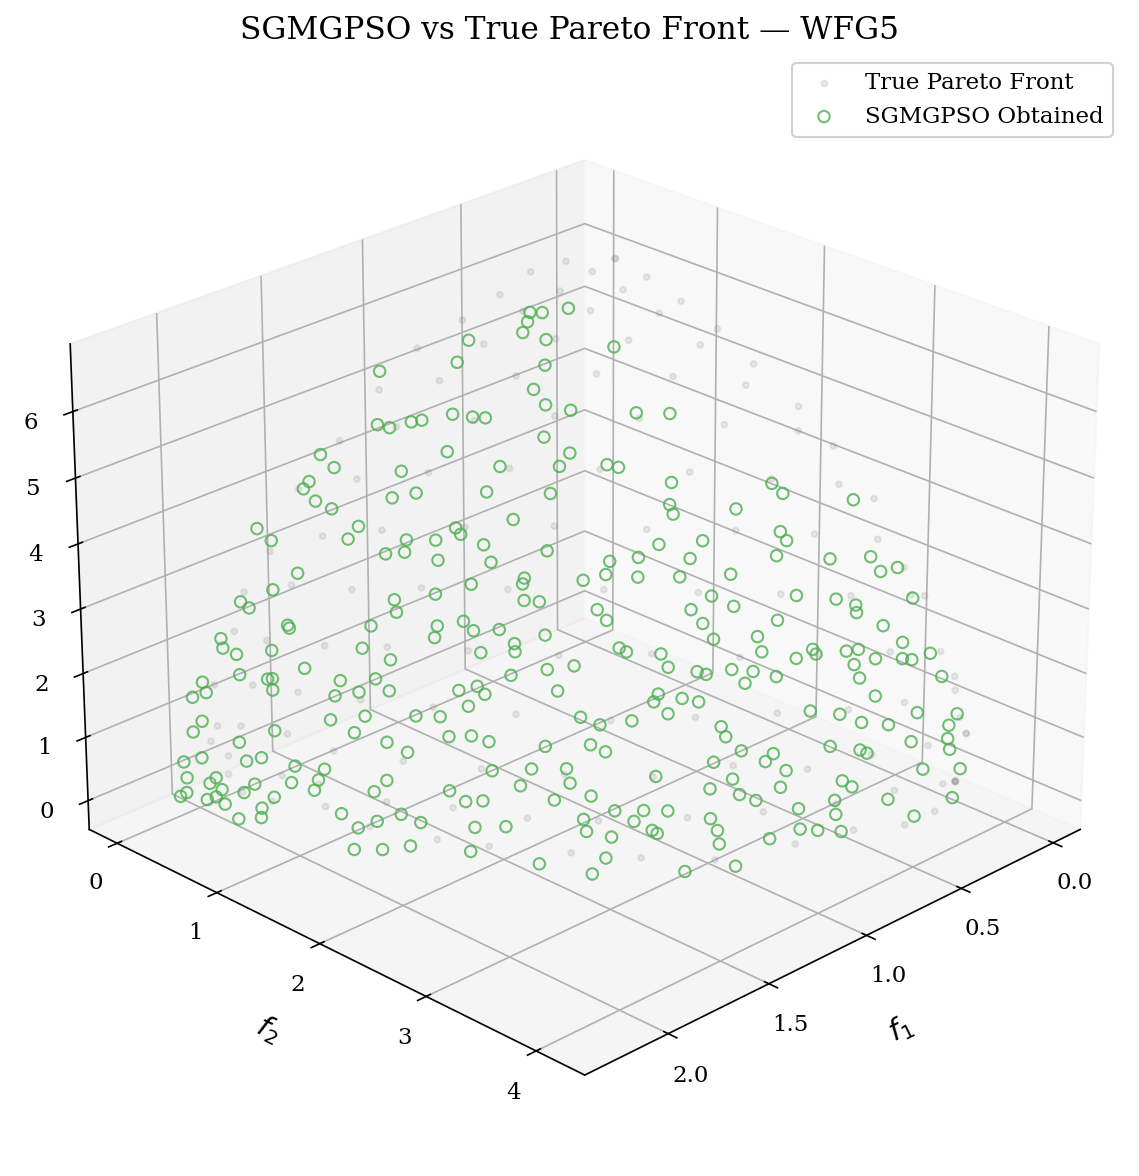


Processing Function: WFG6 (SGMGPSO)
  Trial 30/30 running...
  [Done] WFG6 — 30 trials completed.
  Summary: IGD Mean = 0.383098 ± 0.018112
           HV Mean  = 61.359543 ± 0.923541


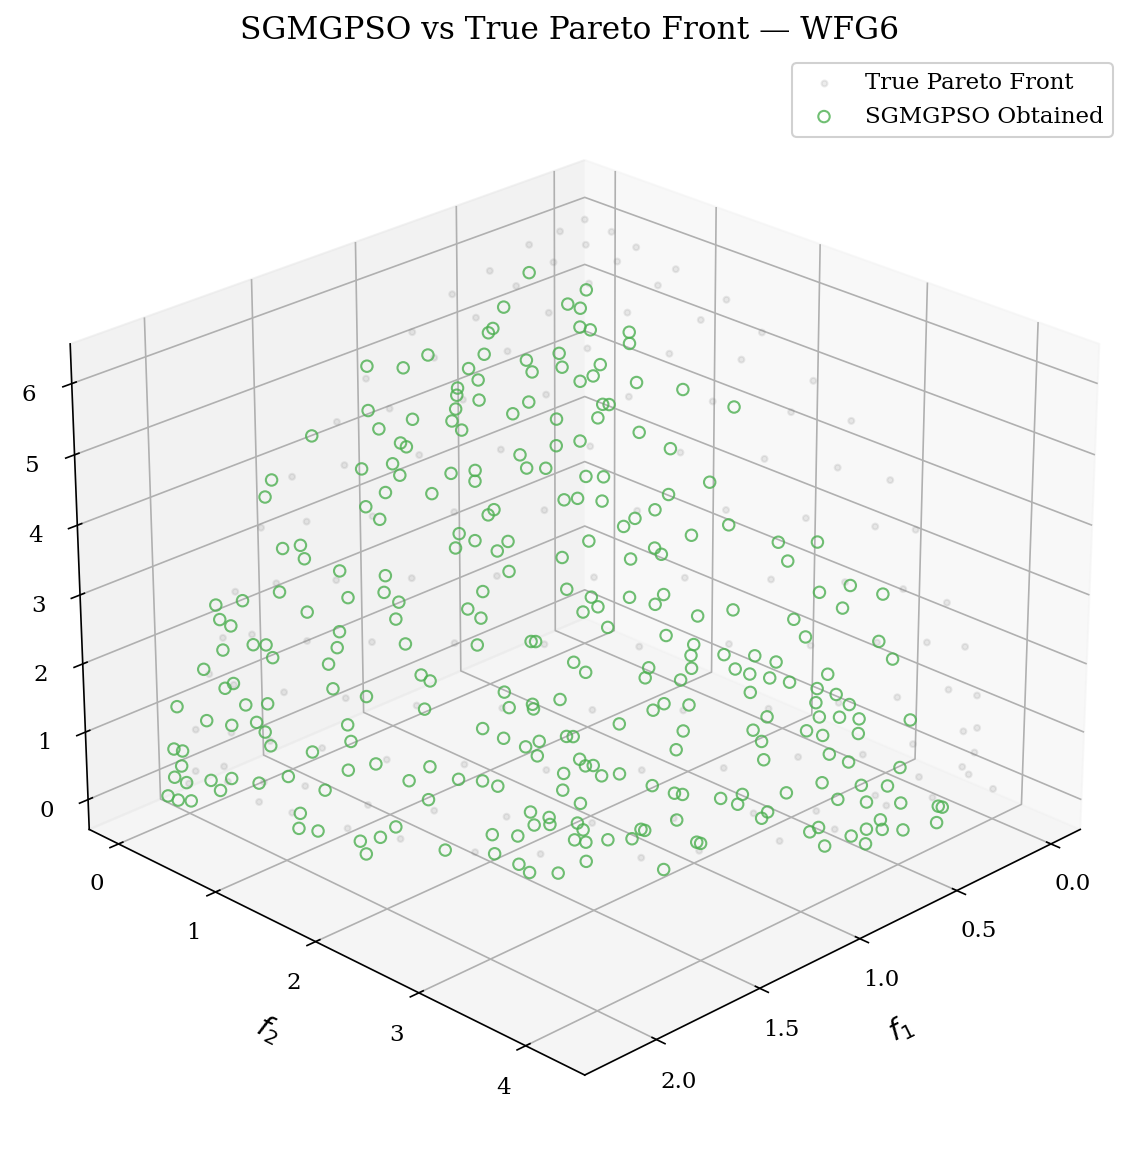


Processing Function: WFG7 (SGMGPSO)
  Trial 30/30 running...
  [Done] WFG7 — 30 trials completed.
  Summary: IGD Mean = 0.388640 ± 0.005236
           HV Mean  = 62.611591 ± 0.293606


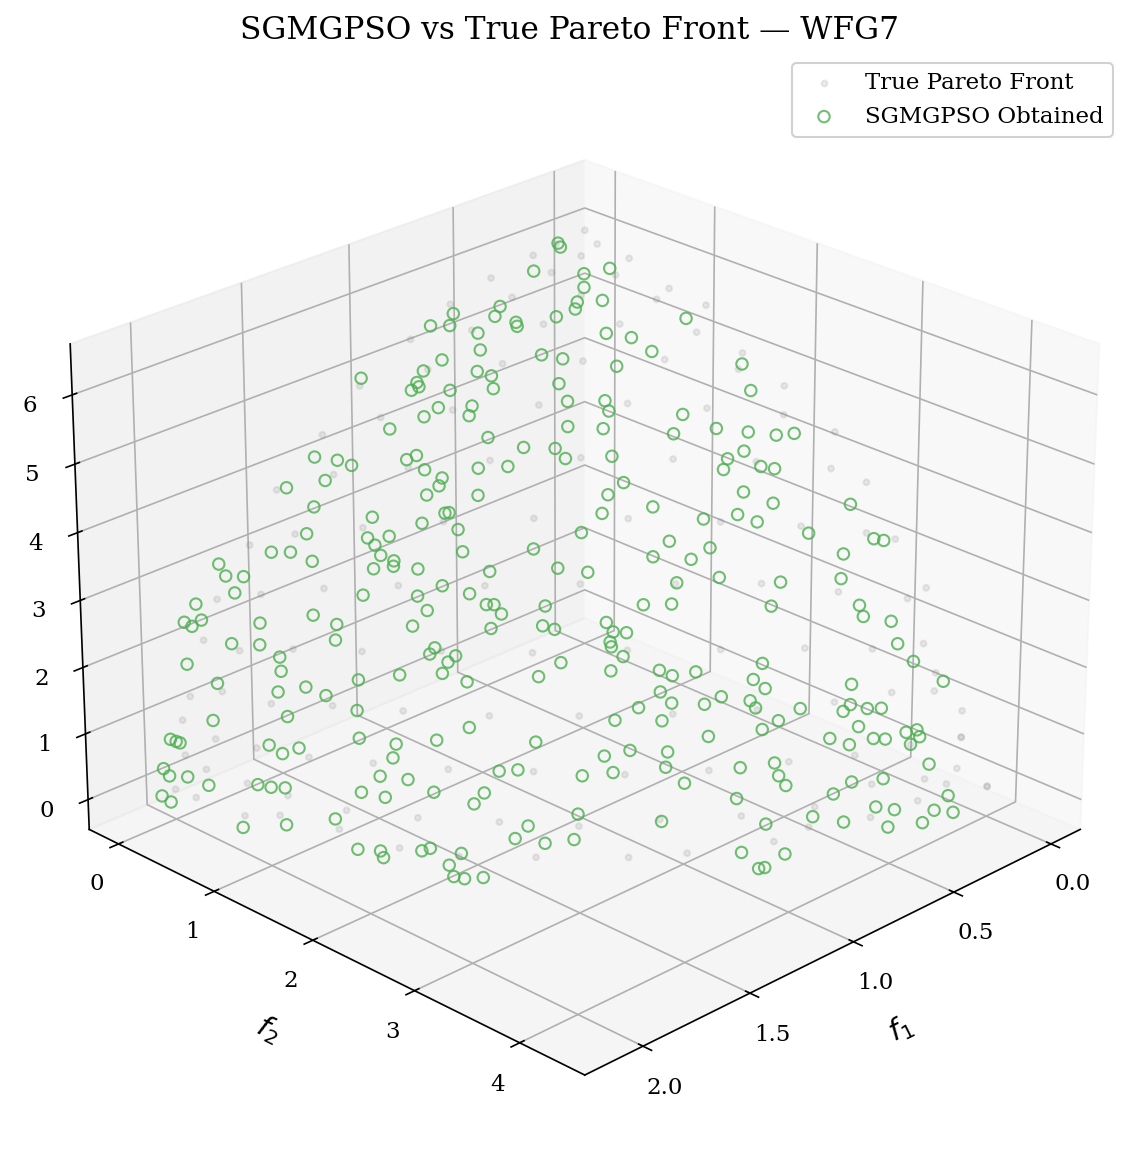


Processing Function: WFG8 (SGMGPSO)
  Trial 30/30 running...
  [Done] WFG8 — 30 trials completed.
  Summary: IGD Mean = 0.516826 ± 0.018369
           HV Mean  = 54.762088 ± 0.927280


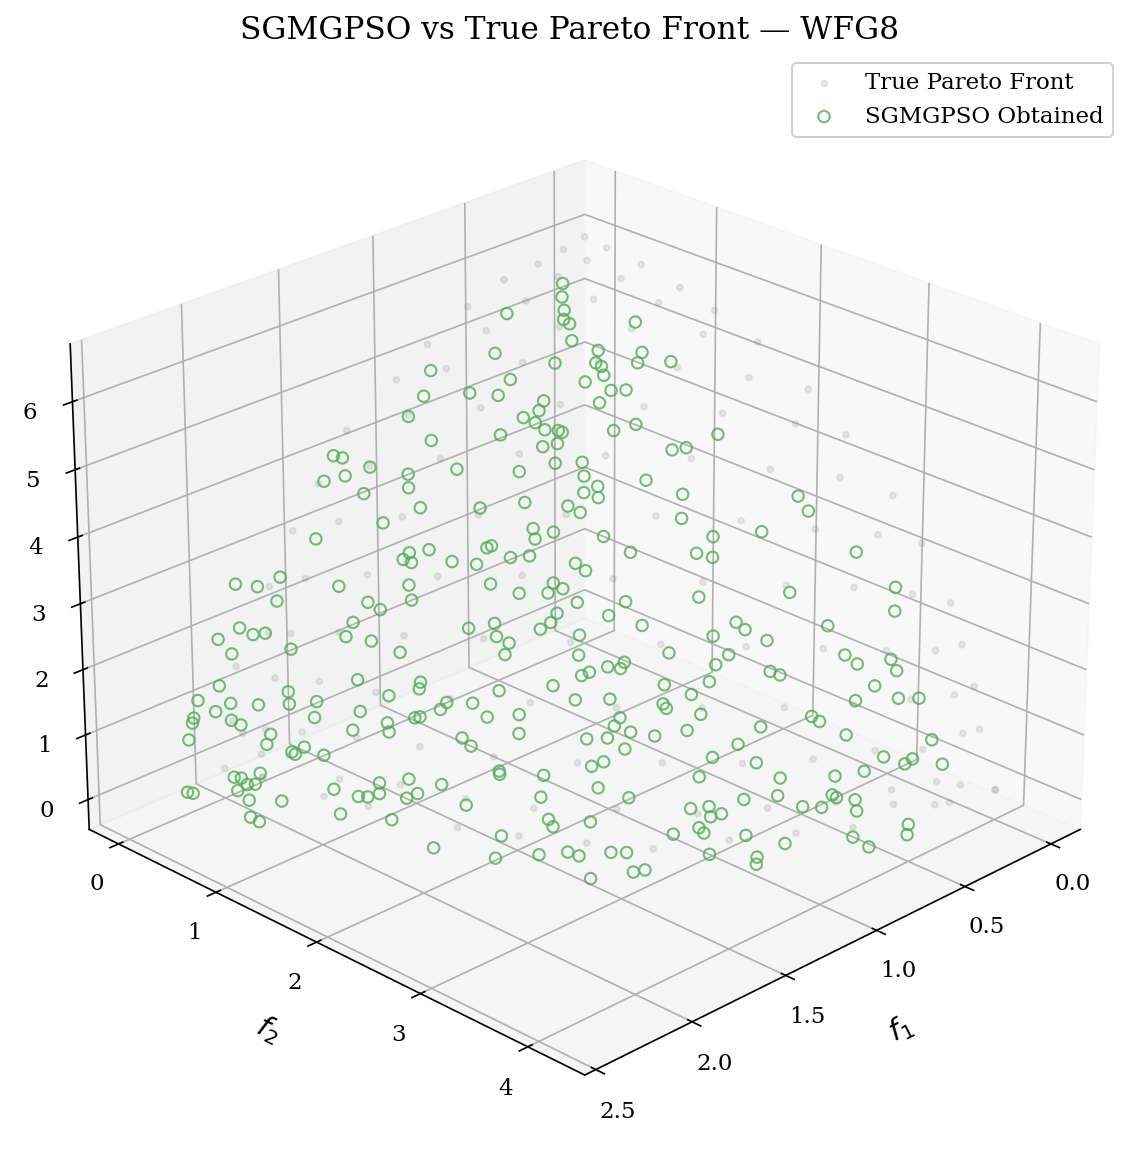


Processing Function: WFG9 (SGMGPSO)
  Trial 30/30 running...
  [Done] WFG9 — 30 trials completed.
  Summary: IGD Mean = 0.258247 ± 0.010960
           HV Mean  = 67.079976 ± 0.541266


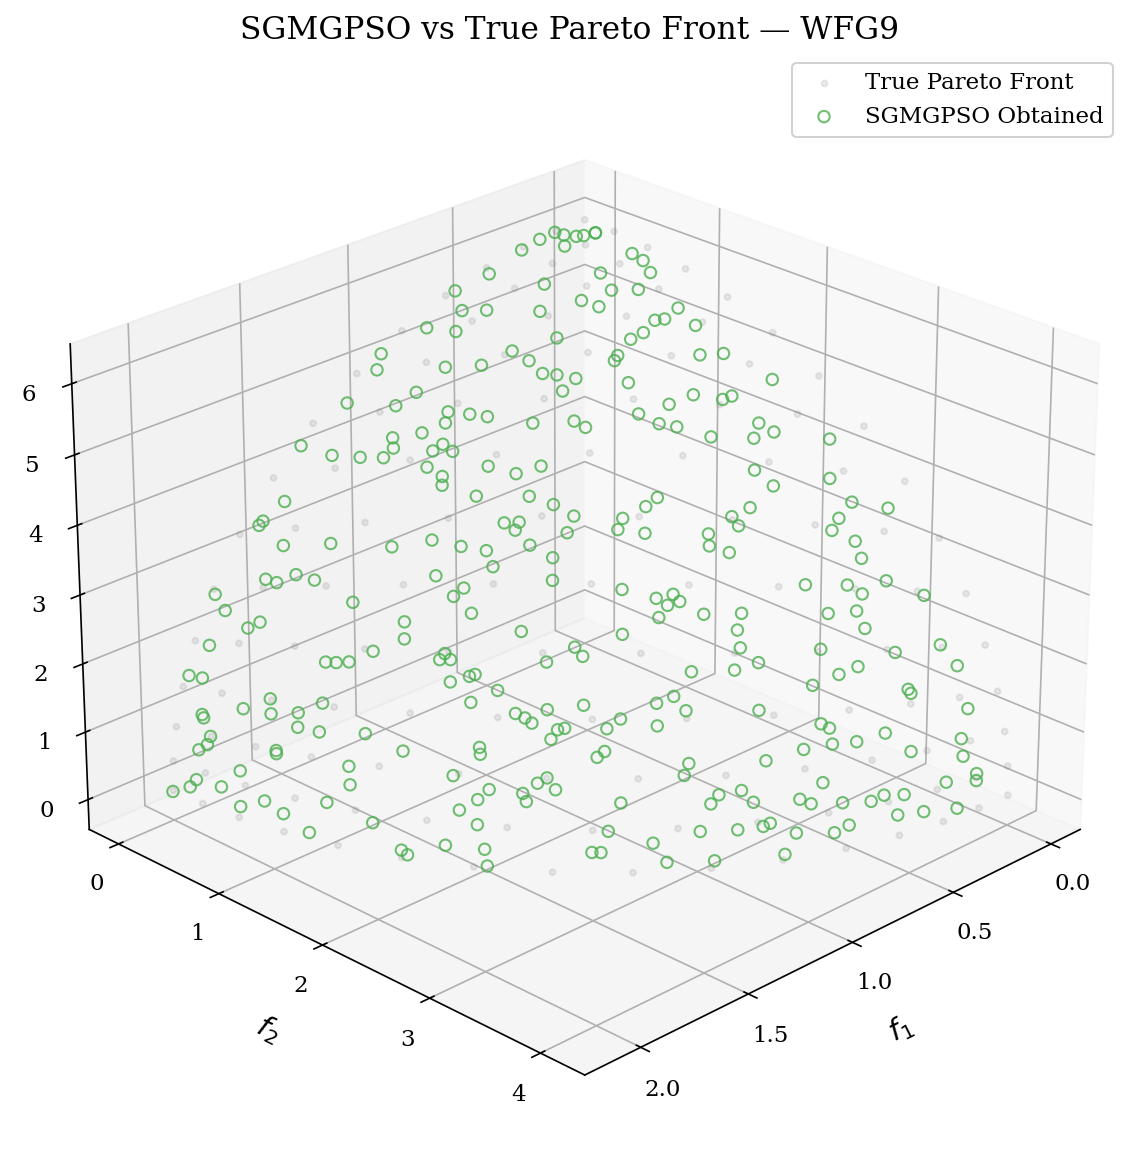


FINAL SUMMARY TABLE — SGMGPSO
Function  IGD_Mean  IGD_Std   HV_Mean   HV_Std
    ZDT1  0.026439 0.009233  5.731267 0.041037
    ZDT2  0.076911 0.039952  4.856004 0.300673
    ZDT3  0.071133 0.020922  6.846284 0.150167
    ZDT4 14.233360 2.577257  0.000000 0.000000
    ZDT6  0.001131 0.000089  5.153512 0.000028
    WFG1  1.441356 0.033543 44.527959 1.104315
    WFG2  0.276901 0.060657 91.832459 2.454494
    WFG3  0.271304 0.016832 64.155366 0.591565
    WFG4  0.235642 0.008257 69.378567 0.458237
    WFG5  0.761689 0.120961 44.466620 4.999990
    WFG6  0.383098 0.018112 61.359543 0.923541
    WFG7  0.388640 0.005236 62.611591 0.293606
    WFG8  0.516826 0.018369 54.762088 0.927280
    WFG9  0.258247 0.010960 67.079976 0.541266


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pymoo.core.population import Population
from pymoo.problems import get_problem
from pymoo.indicators.igd import IGD
from pymoo.indicators.hv import HV
from pymoo.algorithms.moo.nsga2 import RankAndCrowdingSurvival

# ============================================================
# MODEL 3: SGMGPSO (Stability-Guided Multi-Guide PSO)
# Combines stability-based parameter sampling with MGPSO
# ============================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3
})

ALGO_NAME = "SGMGPSO"
N_PARTICLES = 150
ARCHIVE_SIZE = 300
N_RUNS = 30

# --- Reusable Functions ---

def polynomial_mutation(X, xl, xu, eta=20):
    """Polynomial mutation for maintaining search diversity."""
    n, d = X.shape
    prob = 1.0 / d
    mut_mask = np.random.random((n, d)) < prob
    delta = xu - xl
    delta = np.where(delta < 1e-10, 1e-10, delta)
    u = np.random.random((n, d))
    delta1 = np.clip((X - xl) / delta, 0, 1)
    delta2 = np.clip((xu - X) / delta, 0, 1)
    pow_val = 1.0 / (eta + 1.0)
    mask_low = u <= 0.5
    xy = 1.0 - delta1
    val = 2.0 * u + (1.0 - 2.0 * u) * np.power(np.clip(xy, 0, None), eta + 1.0)
    deltaq_low = np.power(np.clip(val, 0, None), pow_val) - 1.0
    xy = 1.0 - delta2
    val = 2.0 * (1.0 - u) + 2.0 * (u - 0.5) * np.power(np.clip(xy, 0, None), eta + 1.0)
    deltaq_high = 1.0 - np.power(np.clip(val, 0, None), pow_val)
    deltaq = np.where(mask_low, deltaq_low, deltaq_high)
    X_mutated = X + deltaq * delta * mut_mask
    return np.clip(X_mutated, xl, xu)

def sample_mgpso_stability():
    """
    Samples MGPSO parameters and checks stability according to Equation 5.
    Improved rejection sampling with tighter bounds for better convergence.
    """
    max_attempts = 50
    for _ in range(max_attempts):
        w = np.random.uniform(0.1, 0.8)
        lambd = np.random.uniform(0.2, 0.8)
        c1 = np.random.uniform(0.5, 2.0)
        c2 = np.random.uniform(0.5, 2.0)
        c3 = np.random.uniform(0.5, 3.0)

        C = c1 + lambd * c2 + (1 - lambd) * c3
        if C <= 0:
            continue
            
        C_var = (c1**2 + (lambd**2)*(c2**2) + ((1-lambd)**2)*(c3**2))
        numerator = 4 * (1 - w**2)
        denominator = (1 - w) + (C_var * (1 + w)) / (3 * (C**2))
        
        if denominator > 0 and 0 < C < (numerator / denominator):
            return w, lambd, c1, c2, c3
    
    # Well-tuned default stable values
    return 0.4, 0.5, 1.2, 1.2, 1.8

def update_archive(problem, archive, new_pop, max_size=ARCHIVE_SIZE):
    """Updates external archive using pymoo's RankAndCrowding survival."""
    if archive is None or len(archive) == 0:
        combined = new_pop
    else:
        combined = Population.merge(archive, new_pop)
    survival = RankAndCrowdingSurvival()
    return survival.do(problem, combined, n_survive=min(len(combined), max_size))

def tournament_selection_archive(archive, size=5):
    """Tournament selection using crowding distance."""
    if len(archive) == 0: return None
    indices = np.random.choice(len(archive), min(size, len(archive)), replace=False)
    candidates = archive[indices]
    cds = candidates.get("crowding")
    if cds is not None:
        cds_safe = np.nan_to_num(cds, nan=0.0, posinf=1e6)
        return candidates[np.argmax(cds_safe)].x
    return candidates[np.random.randint(len(candidates))].x

# --- Main SGMGPSO Logic ---

def run_sgmgpso(problem_obj, n_particles=N_PARTICLES, n_gen=300, seed=0):
    np.random.seed(seed)
    xl, xu = problem_obj.bounds()
    vmax = 0.2 * (xu - xl)  # Velocity clamping
    
    # Initialize Swarm
    X = np.random.uniform(xl, xu, (n_particles, problem_obj.n_var))
    V = np.random.uniform(-0.1 * (xu - xl), 0.1 * (xu - xl), (n_particles, problem_obj.n_var))
    F = problem_obj.evaluate(X)
    pop = Population.new("X", X, "F", F)
    
    pbest_X, pbest_F = np.copy(X), np.copy(F)
    archive = Population()
    archive = update_archive(problem_obj, archive, pop)
    
    for gen in range(n_gen):
        # Sample STABILITY parameters ONCE per iteration
        w, lambd, c1, c2, c3 = sample_mgpso_stability()
        
        for i in range(n_particles):
            # 1. Neighborhood Guide (Ring Topology radius 3)
            nb_idx = np.arange(i - 3, i + 4) % n_particles
            lbest_idx = np.argmin(np.sum(pbest_F[nb_idx], axis=1))
            y_hat = pbest_X[nb_idx[lbest_idx]]
            
            # 2. Archive Guide (a_hat)
            a_hat = tournament_selection_archive(archive, size=5)
            if a_hat is None: a_hat = y_hat
            
            # 3. Velocity Update (Equation 4)
            r1 = np.random.random(problem_obj.n_var)
            r2 = np.random.random(problem_obj.n_var)
            r3 = np.random.random(problem_obj.n_var)
            
            v_pbest = c1 * r1 * (pbest_X[i] - X[i])
            v_neigh = lambd * c2 * r2 * (y_hat - X[i])
            v_arch  = (1 - lambd) * c3 * r3 * (a_hat - X[i])
            
            V[i] = w * V[i] + v_pbest + v_neigh + v_arch
            V[i] = np.clip(V[i], -vmax, vmax)  # Velocity clamping
            X[i] = np.clip(X[i] + V[i], xl, xu)
            
        # Apply mutation
        X = polynomial_mutation(X, xl, xu, eta=20)
        
        F = problem_obj.evaluate(X)
        pop = Population.new("X", X, "F", F)
        
        for i in range(n_particles):
            if np.all(F[i] <= pbest_F[i]) and np.any(F[i] < pbest_F[i]):
                pbest_X[i], pbest_F[i] = np.copy(X[i]), np.copy(F[i])
            elif not (np.all(pbest_F[i] <= F[i]) and np.any(pbest_F[i] < F[i])):
                if np.random.random() < 0.5:
                    pbest_X[i], pbest_F[i] = np.copy(X[i]), np.copy(F[i])
                
        archive = update_archive(problem_obj, archive, pop)

    return archive

# --- Publication-Quality Plotting ---

def plot_pareto_comparison_2d(pf, obtained_F, algo_name, func_name, output_path, color='#4CAF50'):
    fig, ax = plt.subplots(figsize=(8, 6))
    if pf is not None:
        sorted_pf = pf[pf[:, 0].argsort()]
        ax.plot(sorted_pf[:, 0], sorted_pf[:, 1], color='black', lw=2.0, 
                label='True Pareto Front', alpha=0.85, zorder=5)
    ax.scatter(obtained_F[:, 0], obtained_F[:, 1], facecolor='none', 
              edgecolor=color, s=40, linewidths=1.2, 
              label=f'{algo_name} Obtained', alpha=0.85, zorder=10)
    ax.set_xlabel(r'$f_1$')
    ax.set_ylabel(r'$f_2$')
    ax.set_title(f'{algo_name} vs True Pareto Front — {func_name}')
    ax.legend(loc='best', framealpha=0.9)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_pareto_comparison_3d(pf, obtained_F, algo_name, func_name, output_path, color='#4CAF50'):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    if pf is not None:
        ax.scatter(pf[:, 0], pf[:, 1], pf[:, 2], c='gray', s=8, 
                  label='True Pareto Front', alpha=0.15, zorder=1)
    ax.scatter(obtained_F[:, 0], obtained_F[:, 1], obtained_F[:, 2], 
             facecolor='none', edgecolor=color, s=30, linewidths=1.0,
             label=f'{algo_name} Obtained', alpha=0.8, zorder=10)
    ax.set_xlabel(r'$f_1$', labelpad=10)
    ax.set_ylabel(r'$f_2$', labelpad=10)
    ax.set_zlabel(r'$f_3$', labelpad=10)
    ax.set_title(f'{algo_name} vs True Pareto Front — {func_name}')
    ax.legend(loc='best', framealpha=0.9)
    ax.view_init(elev=25, azim=45)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# --- Experiment Runner ---

def main():
    benchmarks = ["zdt1", "zdt2", "zdt3", "zdt4", "zdt6", 
                  "wfg1", "wfg2", "wfg3", "wfg4", "wfg5", "wfg6", "wfg7", "wfg8", "wfg9"]
    
    all_results = []
    
    for b_name in benchmarks:
        print(f"\n{'='*60}")
        print(f"Processing Function: {b_name.upper()} ({ALGO_NAME})")
        print(f"{'='*60}")
        output_dir = f"./results/{ALGO_NAME}/{b_name}/"
        os.makedirs(output_dir, exist_ok=True)
        
        is_wfg = b_name.lower().startswith("wfg")
        problem = get_problem(b_name, n_var=24, n_obj=3, k=4) if is_wfg else get_problem(b_name)
        
        n_gen = 400 if is_wfg else 300
        if b_name.lower() == 'zdt4':
            n_gen = 500
        
        pf = problem.pareto_front()
        ref_point = np.array([3.0, 5.0, 7.0]) if is_wfg else np.ones(problem.n_obj) * 2.5
        
        run_results = []
        best_igd = np.inf
        best_F = None
        
        for run in range(N_RUNS):
            print(f"  Trial {run + 1}/{N_RUNS} running...", end="\r")
            res_archive = run_sgmgpso(problem, n_gen=n_gen, seed=run)
            F = res_archive.get("F")
            
            if pf is not None:
                igd = IGD(pf).do(F)
                hv = HV(ref_point=ref_point).do(F)
            else:
                igd, hv = np.nan, np.nan
            run_results.append({"run": run + 1, "IGD": igd, "HV": hv})
            
            if igd < best_igd:
                best_igd = igd
                best_F = F.copy()
            
        print(f"\n  [Done] {b_name.upper()} — {N_RUNS} trials completed.")
        df = pd.DataFrame(run_results)
        df.to_csv(f"{output_dir}metrics.csv", index=False)
        
        igd_mean, igd_std = df['IGD'].mean(), df['IGD'].std()
        hv_mean, hv_std = df['HV'].mean(), df['HV'].std()
        
        print(f"  Summary: IGD Mean = {igd_mean:.6f} ± {igd_std:.6f}")
        print(f"           HV Mean  = {hv_mean:.6f} ± {hv_std:.6f}")
        
        all_results.append({
            'Function': b_name.upper(),
            'IGD_Mean': igd_mean, 'IGD_Std': igd_std,
            'HV_Mean': hv_mean, 'HV_Std': hv_std
        })
        
        if problem.n_obj == 2:
            plot_pareto_comparison_2d(pf, best_F, ALGO_NAME, b_name.upper(),
                                     f"{output_dir}pareto_front_comparison.png")
        else:
            plot_pareto_comparison_3d(pf, best_F, ALGO_NAME, b_name.upper(),
                                     f"{output_dir}pareto_front_comparison.png")
    
    print(f"\n{'='*80}")
    print(f"FINAL SUMMARY TABLE — {ALGO_NAME}")
    print(f"{'='*80}")
    summary_df = pd.DataFrame(all_results)
    summary_df.to_csv(f"./results/{ALGO_NAME}/summary.csv", index=False)
    print(summary_df.to_string(index=False))

if __name__ == "__main__":
    main()